### 1. Load Data

In [24]:
import pandas as pd 


df = pd.read_csv('Data/house-prices-advanced-regression-techniques/train.csv')
df.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [25]:
df_id = df.drop(columns=['Id'])
df_id.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Pemisahan kolom berdasarkan tipe datanya. Disini kita akan menggunakan kolom nummeric saja


In [26]:
df_tipe_num = df_id.select_dtypes(include=['float64', 'int64'])
df_tipe_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


In [27]:
df_tipe_num.nunique() # Untuk mengetahui nilai apa saja yang ada pada setiap kolom

MSSubClass         15
LotFrontage       110
LotArea          1073
OverallQual        10
OverallCond         9
YearBuilt         112
YearRemodAdd       61
MasVnrArea        327
BsmtFinSF1        637
BsmtFinSF2        144
BsmtUnfSF         780
TotalBsmtSF       721
1stFlrSF          753
2ndFlrSF          417
LowQualFinSF       24
GrLivArea         861
BsmtFullBath        4
BsmtHalfBath        3
FullBath            4
HalfBath            3
BedroomAbvGr        8
KitchenAbvGr        4
TotRmsAbvGrd       12
Fireplaces          4
GarageYrBlt        97
GarageCars          5
GarageArea        441
WoodDeckSF        274
OpenPorchSF       202
EnclosedPorch     120
3SsnPorch          20
ScreenPorch        76
PoolArea            8
MiscVal            21
MoSold             12
YrSold              5
SalePrice         663
dtype: int64

Data object atau string

### 2. Visualisasi Data

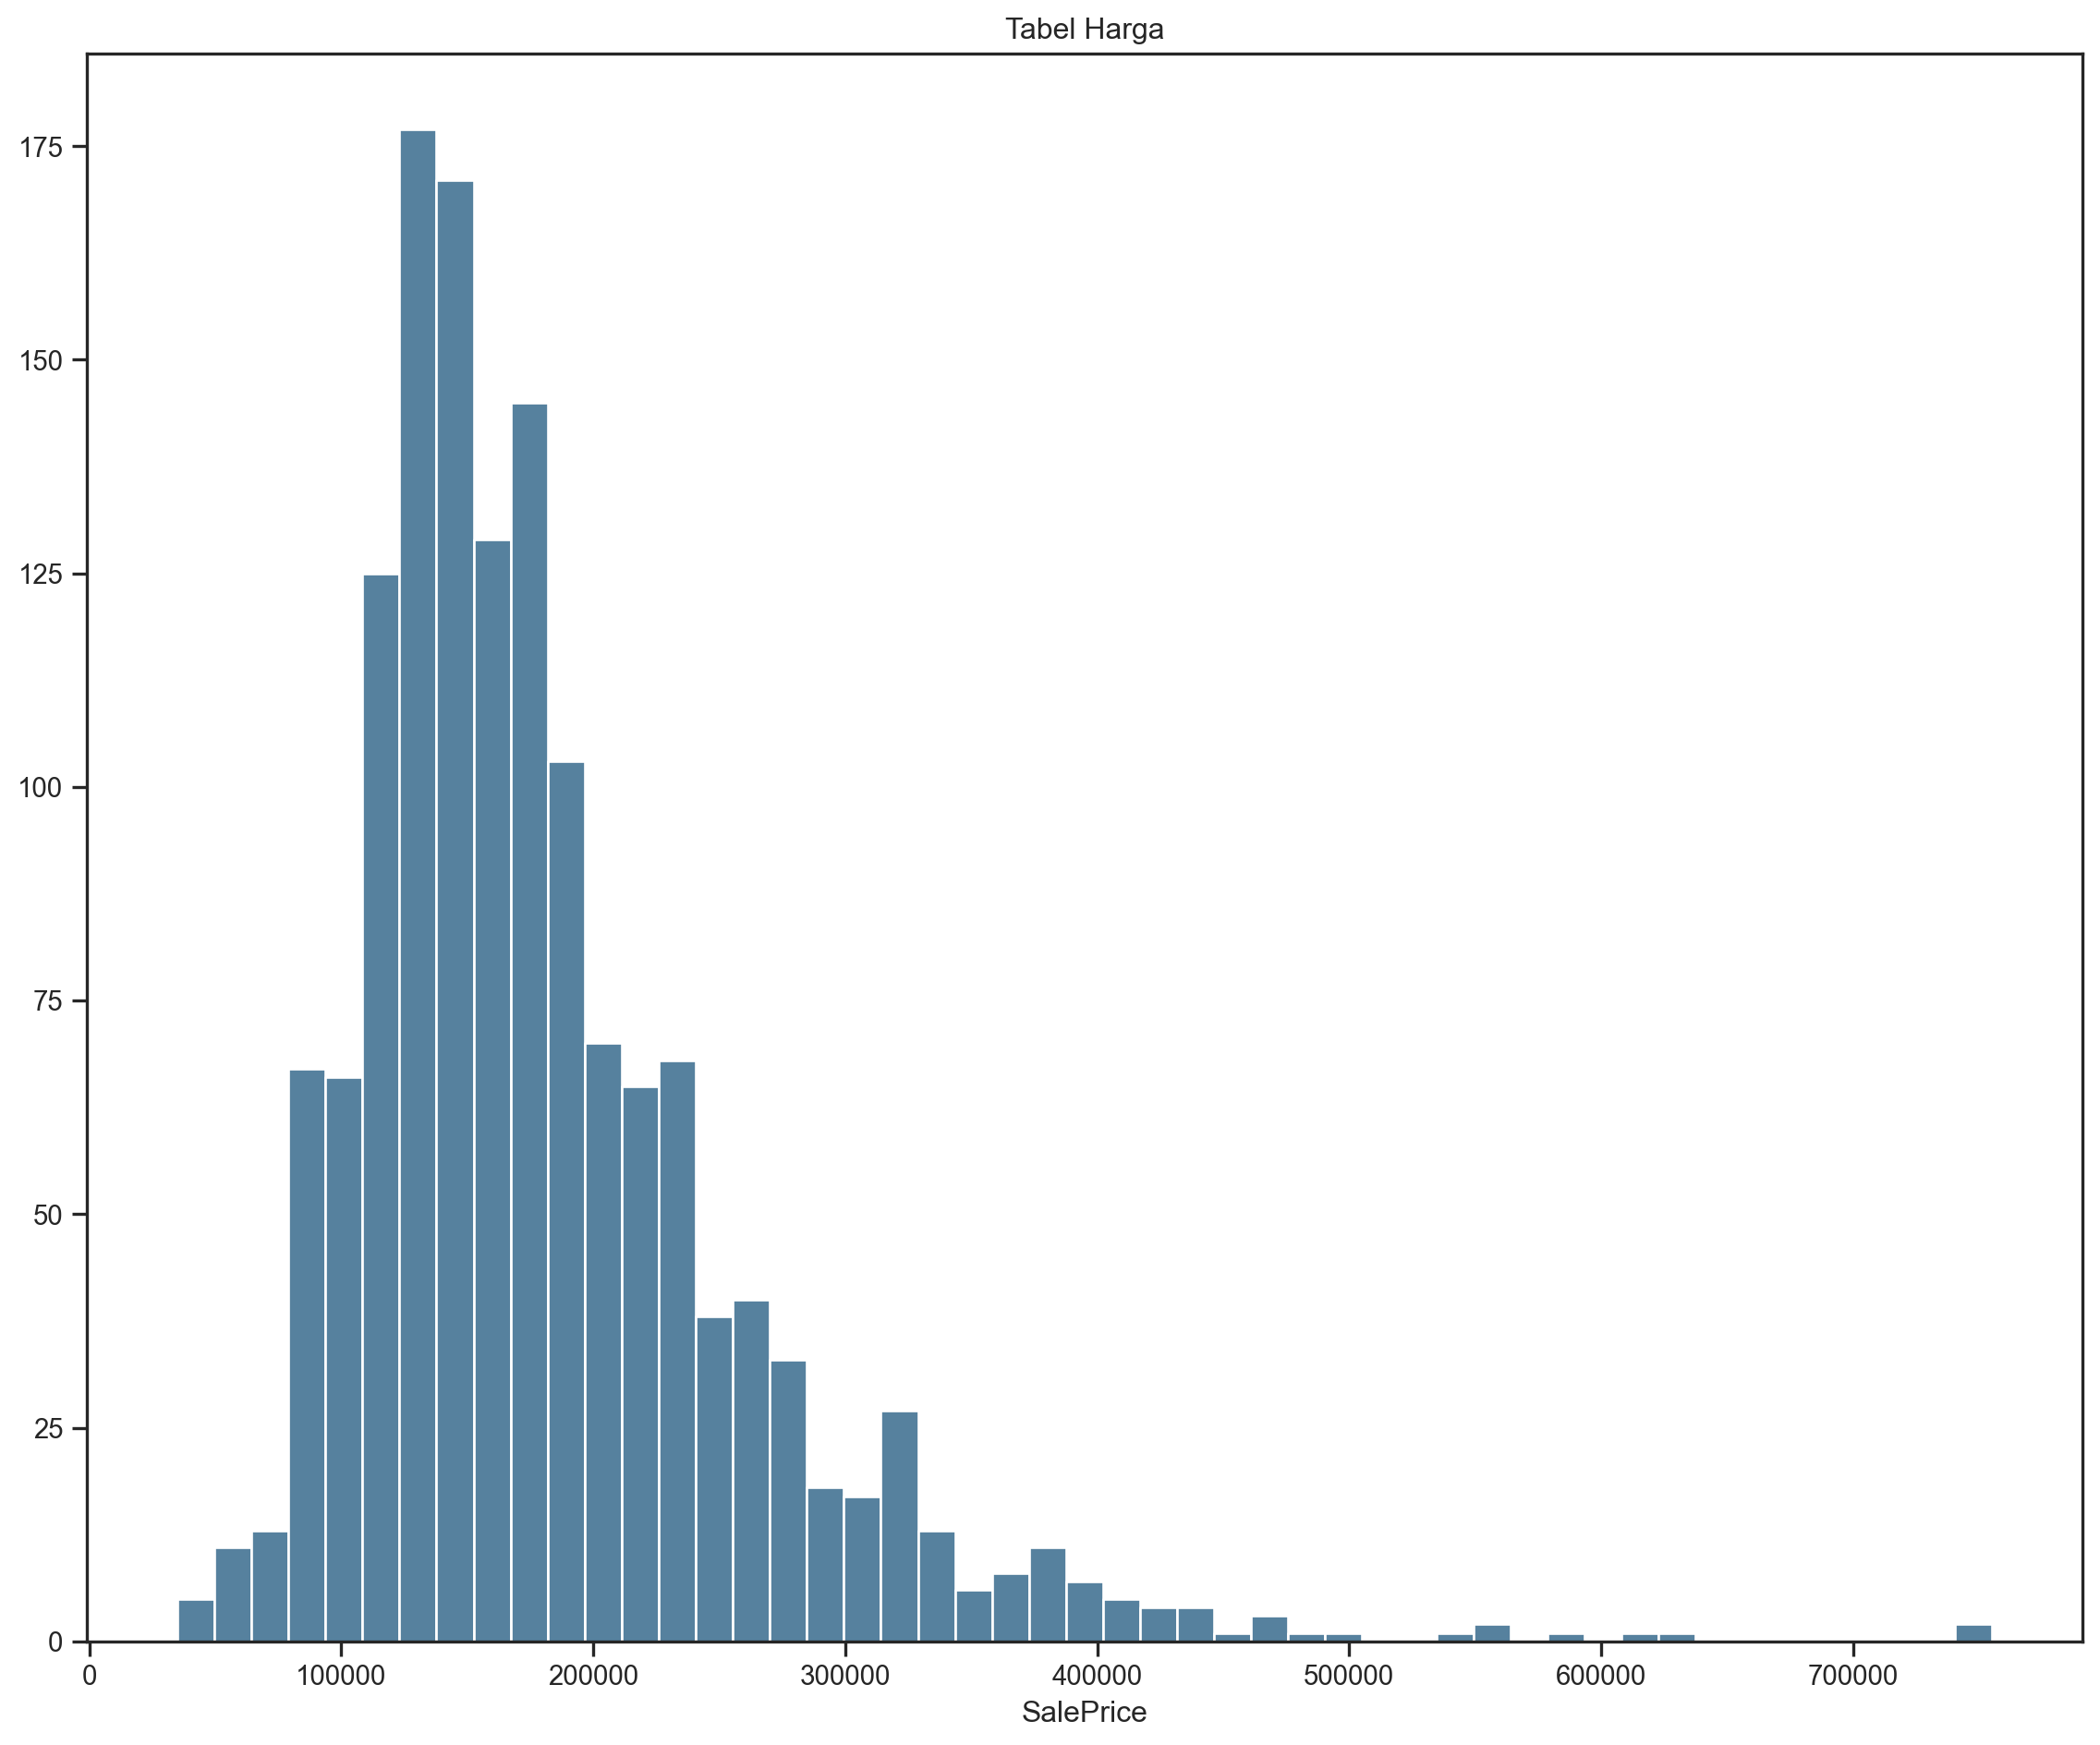

In [28]:
import seaborn.objects as so
import matplotlib.pyplot as plt 
import seaborn as sns
from seaborn import axes_style

tabel=df_tipe_num['SalePrice'].describe()
desc = so.Plot(df_tipe_num, 'SalePrice').add(so.Bars(color="#0F4C75"), so.Hist()).layout(size=(12,10)).label(title="Tabel Harga").theme(axes_style("ticks"))
desc

Text(0.5, 1.0, 'Tabel Korelasi')

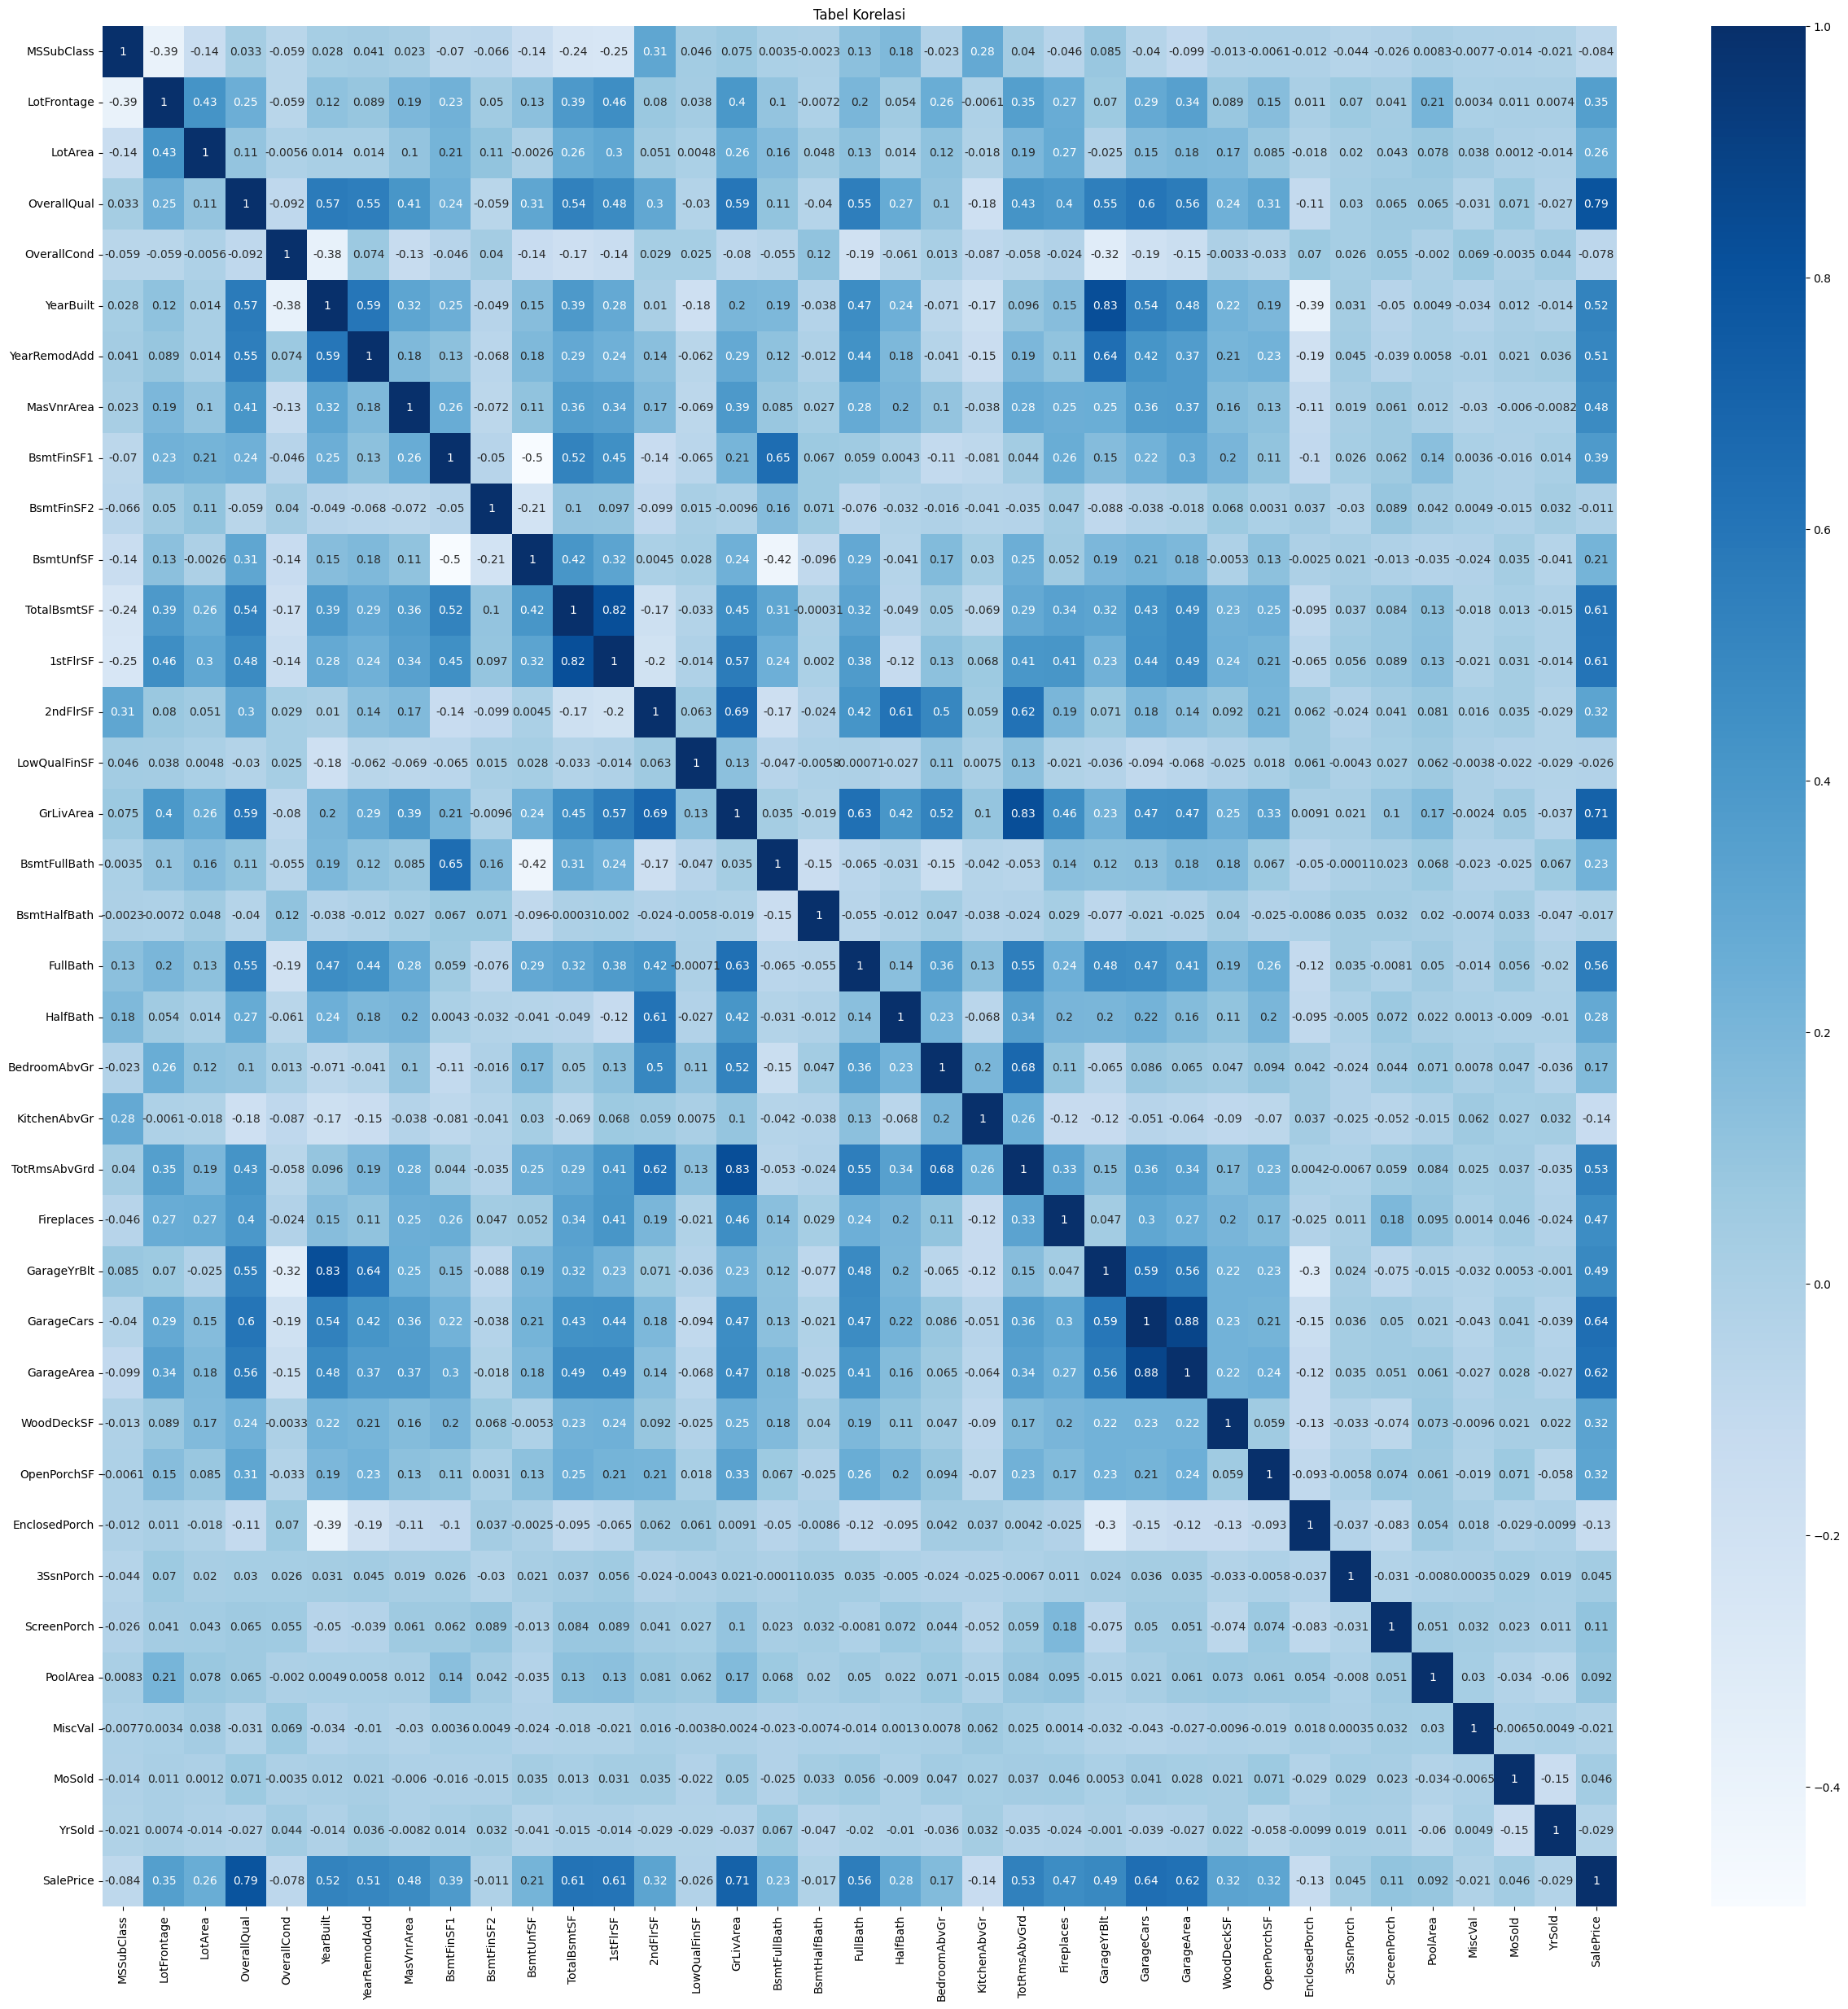

In [29]:


df_cor = df_tipe_num.corr()

fig, ax = plt.subplots(figsize=(30,30))
sns.heatmap(df_cor, cmap='Blues', annot=True, ax=ax)
ax.set_title('Tabel Korelasi')

Mari kita coba menganalisa dan memvisualisasikan korelasi diatas 0.50 terlebih dahulu

In [30]:
df_tipe_num["OverallQual"].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

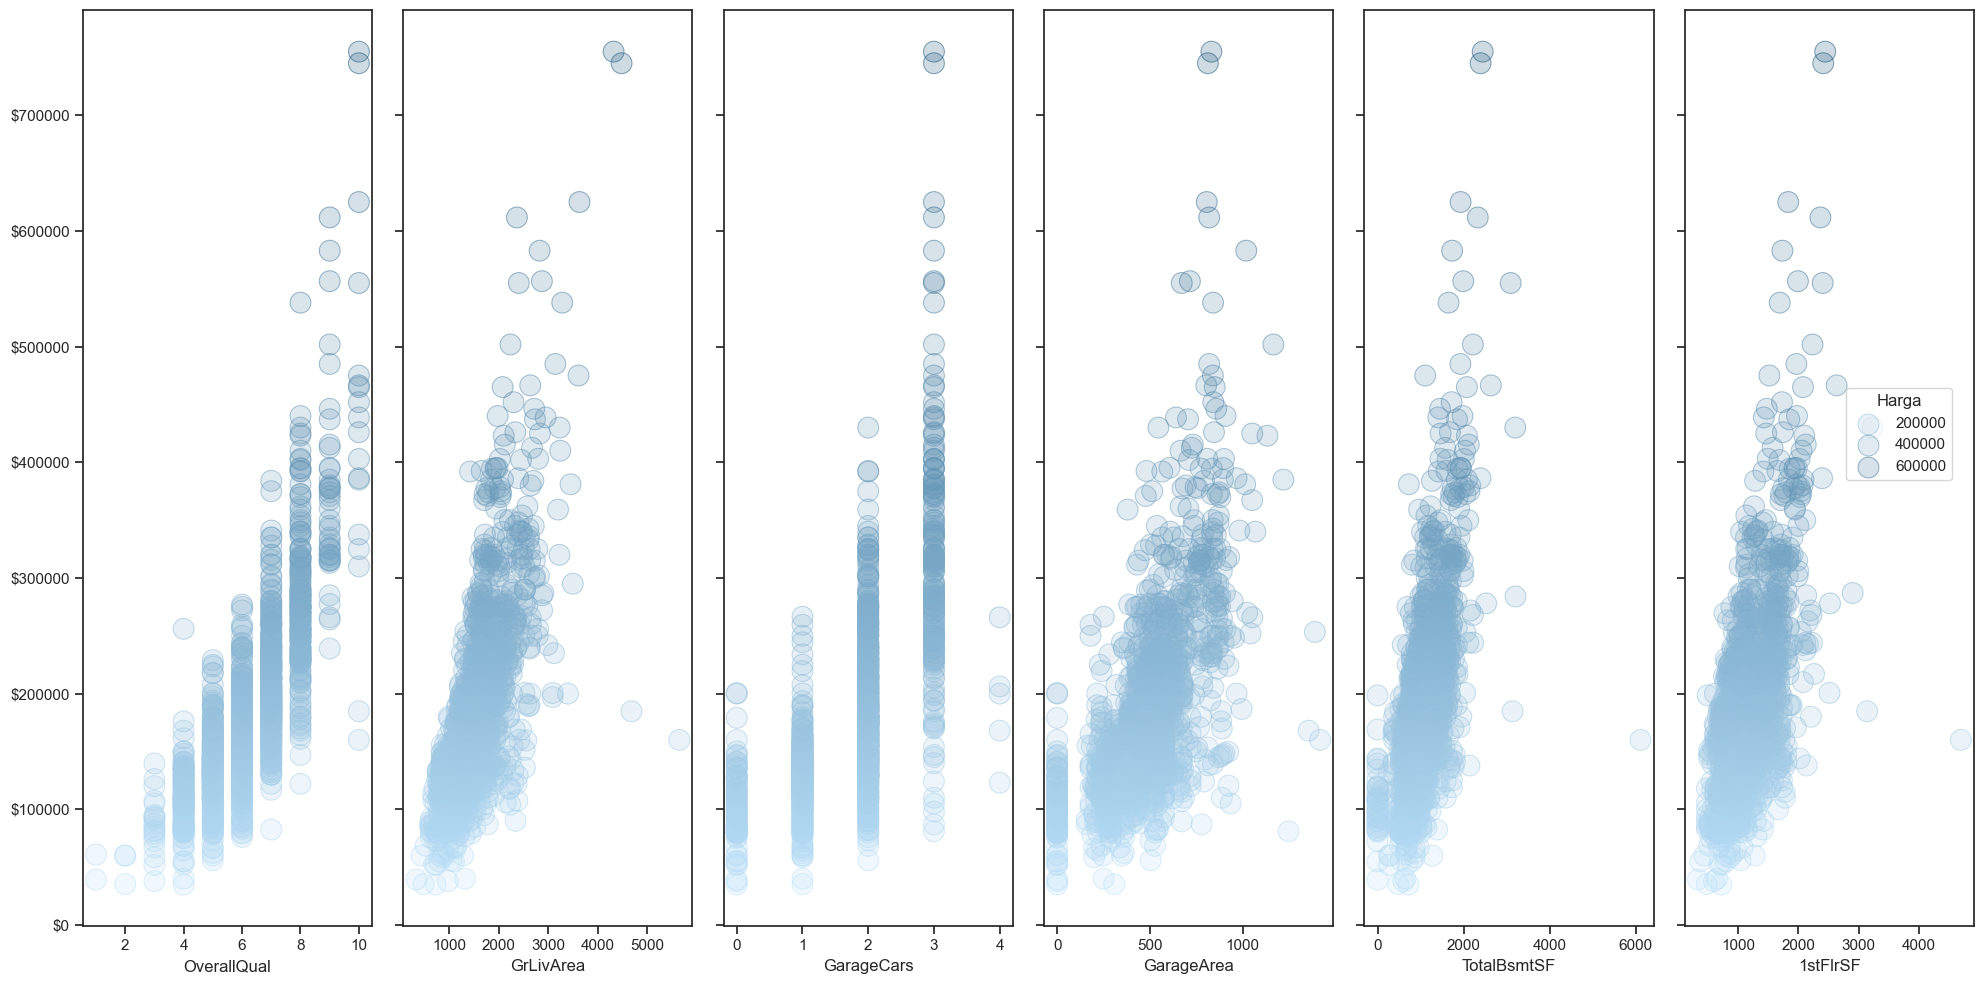

In [31]:
p = so.Plot(df_tipe_num, y='SalePrice', color='SalePrice').theme(axes_style("ticks")) #Tabel Plot untuk mengetahui harga 
p.add(so.Dots(alpha=.5, pointsize=15)).scale(
    y=so.Continuous().label(like="${x:g}"),
    color=so.Continuous(('#BBE1FA', '#0F4C75'))
    ).layout(size=(20,10)).pair(x=['OverallQual', 'GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF']).label( color='Harga', y='', legend="Measurement").show()


Tabel diatas memiliki pola yang sama yaitu *menaik* atau semakin gelap jika kita korelasikan dengan Harga Jual

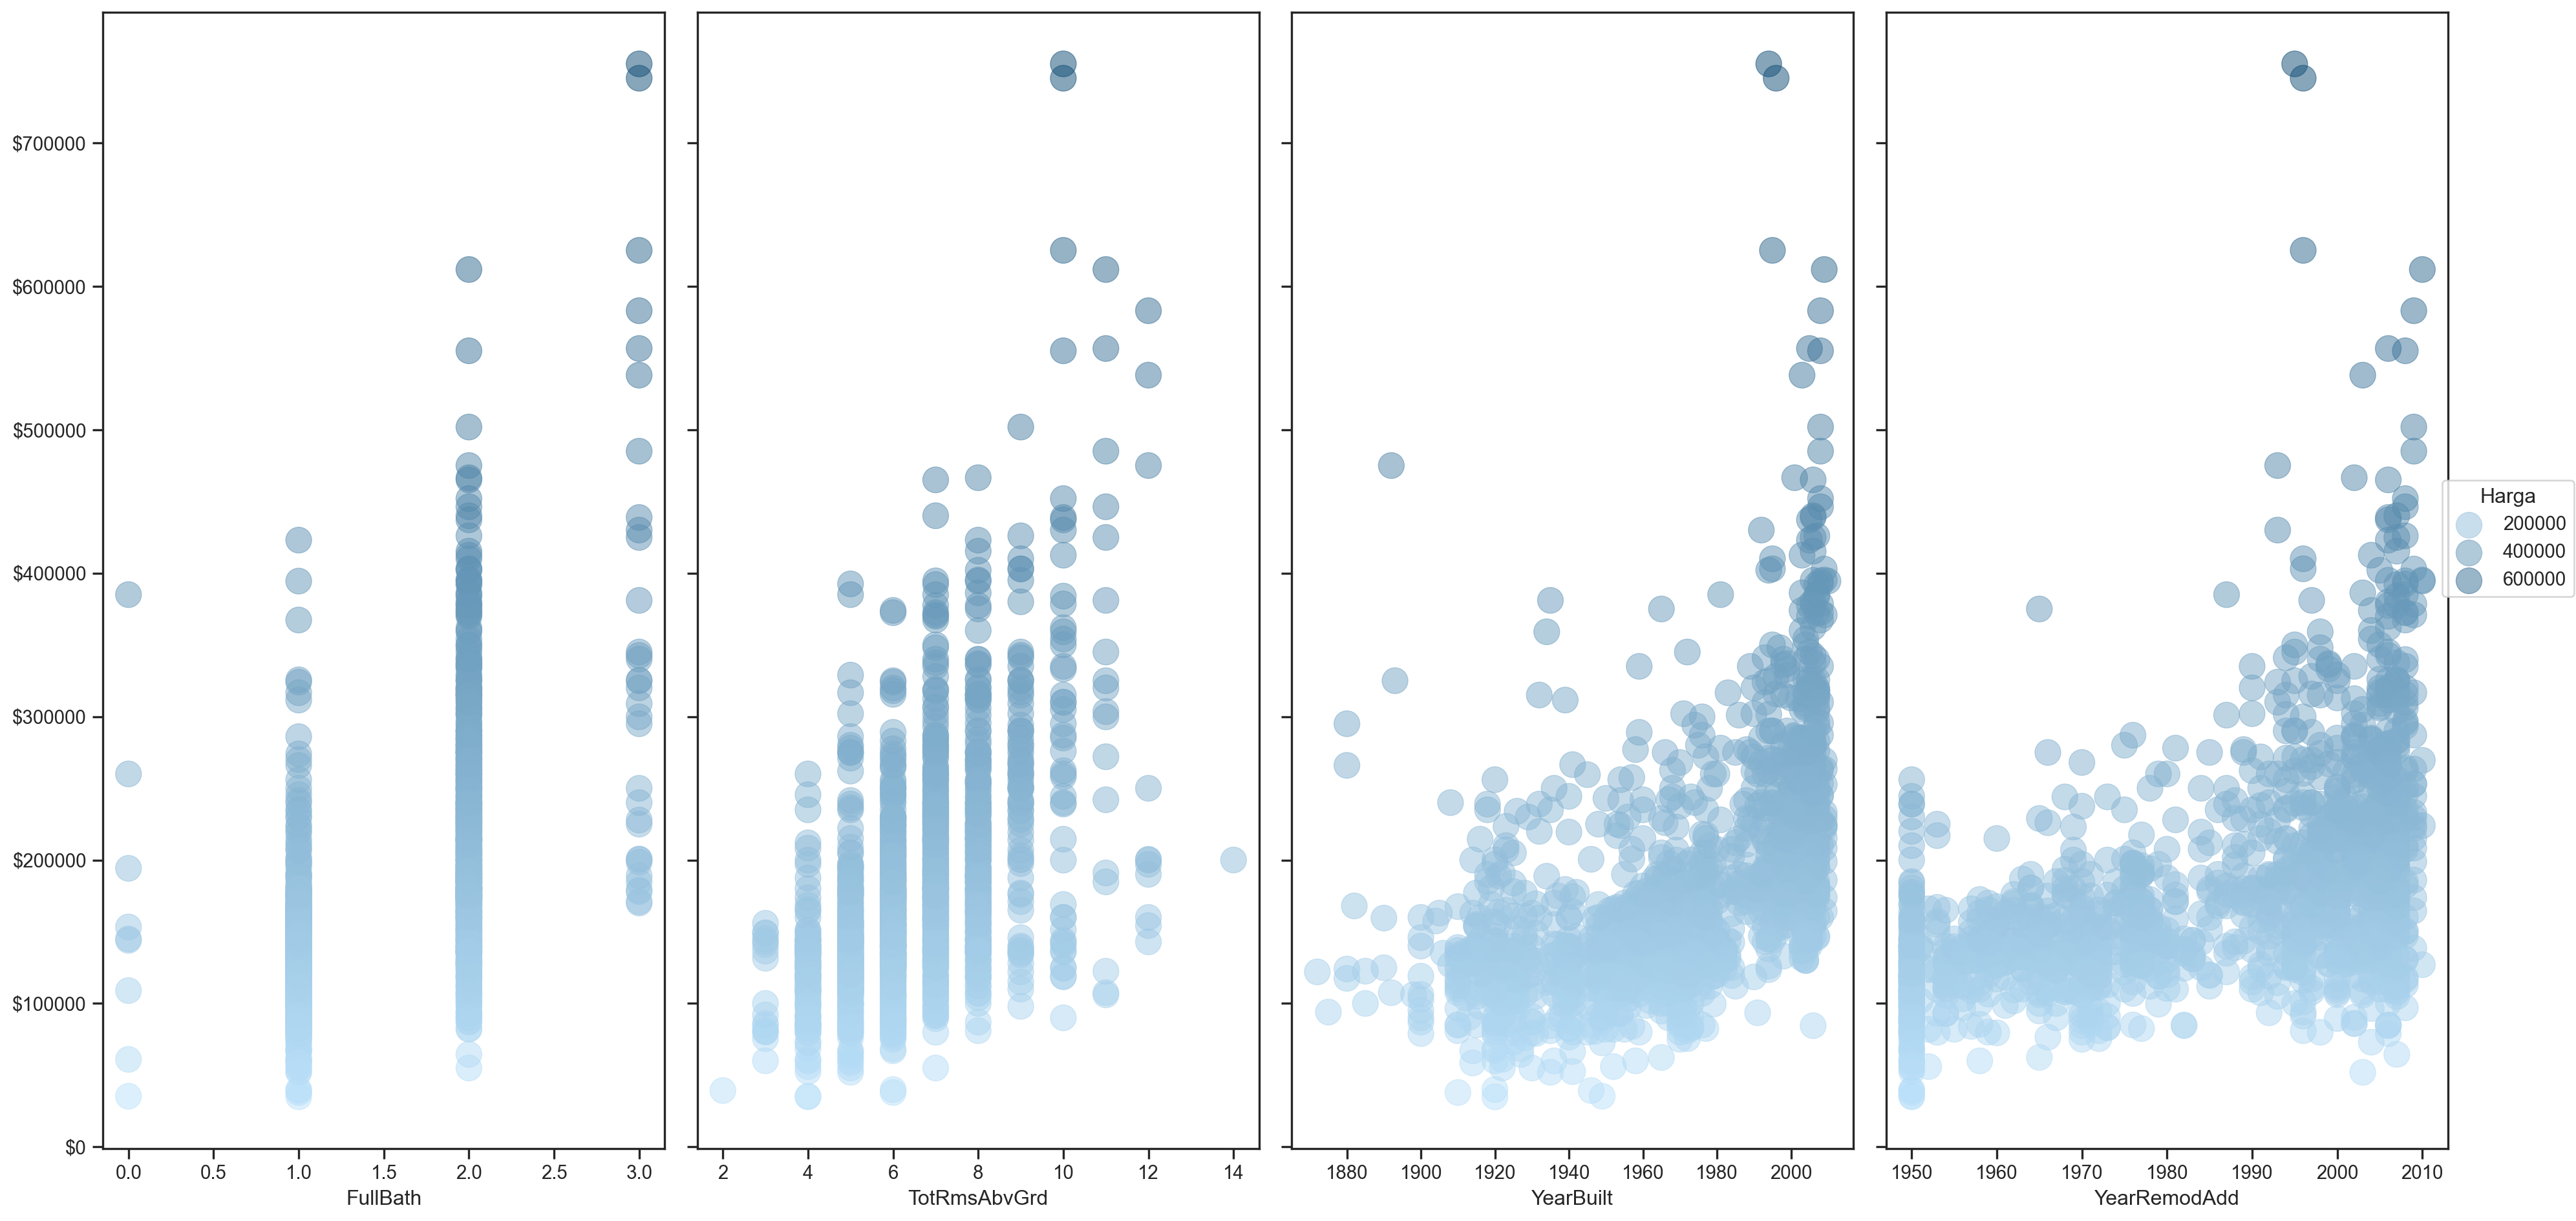

In [32]:
q = so.Plot(df_tipe_num, y='SalePrice', color='SalePrice').theme(axes_style("ticks"))
q.add(so.Dot(alpha=.5, pointsize=15)).scale(
    y=so.Continuous().label(like="${x:g}"),
    color=so.Continuous(('#BBE1FA', '#0F4C75'))
    ).layout(size=(20,10)).label().pair(x=['FullBath','TotRmsAbvGrd','YearBuilt','YearRemodAdd']).label( color='Harga', y='')

### 3. Pemilihan Model Estimator


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor # Model estimator
from sklearn.model_selection import train_test_split # Pemilihan dan evaluasi model

X = df_tipe_num.drop(columns=["SalePrice"]) # Feature
y = df_tipe_num["SalePrice"] # Target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=1) # Pembagian untuk data train dan test
model = HistGradientBoostingRegressor(min_samples_leaf=10)
model.fit(X_train,y_train)
model.score(X_test,y_test)


0.856675119295297